# Evaluation notes SISAP 2025

- Please take into account that `buildtime` and `querytime` are self-reported; both must be consistent with `total_time`; some were set to a special value to indicate the missing value, e.g., 1e9.
- `total_time` contains the runnning time of the docker container; this includes loading data, any preprocessing (dimensional reduction), index construction, searching time, any postprocessing (e.g., reranking). Computational power: 8 cpus; 16g RAM; about swap:
  * ~~hforest seems to use a different algorithm when swap-mem is available, the result here is with swap-mem that is the faster one~~
  * Requires about one extra gigabyte of memory (swap) to work.
    * BrownCICESE in _task1_.
    * DCC-Chile in _task 2_.
    * hforest seems to use a different algorithm without enough memory in _task 1_; _task 2_ runs okay in 16GB (an error annotation in the previous version of this notebook)
    * Others run okay without extra memory, you can see a memory report of all solutions at the end of this notebook.
    
The memory usage analysis was made through sampling the memory process every 4 seconds, i.e., some _allocations_ and _free_-ing can occur between memory samples and produce memory errors. One gigabyte of swap solved the problem in our evaluation procedure. Our criteria is that partipants were unable to remain behind memory limits due to technical details (i.e., overhead of the docker system, the runtime of the framework used, etc.) and tried to fulfull on the algorithm-side of the challenge.

- Some teams didn't specify an algorithm field so it is the same than `team` or even missing.
- This results were measured with the `evaluation` dataset; which are different permutations and subsets of the same original data than the `develop` dataset.
- `params` are self-reported and have different formats


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("results-sisap25.csv")

In [3]:
def nickname(name):
    if name == "ABS-BLINE":
        return "BL-SearchGraph"
    elif name == "BF-BLINE":
        return "BL-Bruteforce"
    elif name == "MetricSearch":
        return "Crusty Coders"
    else:
        return name

df["team"] = df.team.map(nickname)
df.team.unique()


array(['BL-SearchGraph', 'BL-Bruteforce', 'DCC-UChile',
       'TeamDoubleFiltering', 'Crusty Coders', 'hforest', 'cc-lll',
       'BrownCICESE', 'JLapeyra'], dtype=object)

# Task 1

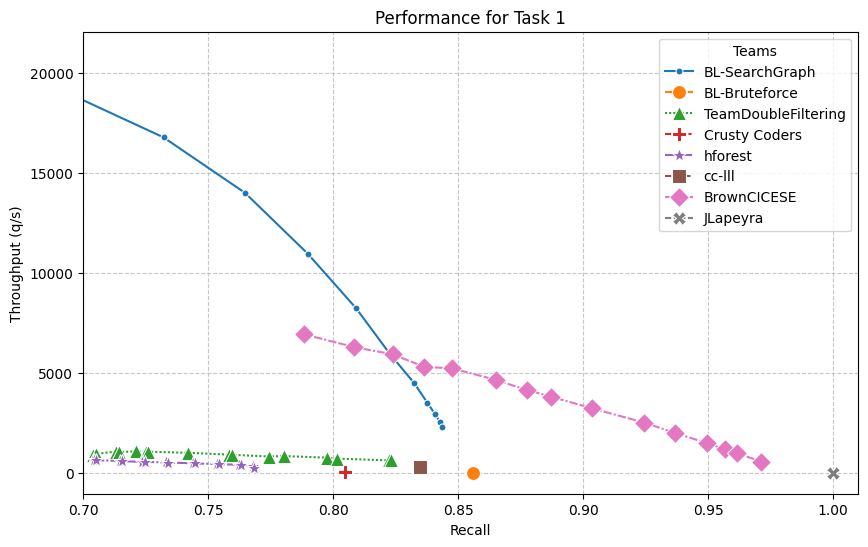

In [4]:
plt.figure(figsize=(10, 6))
#task1 = df[df.task == 'task1']
task1 = df.query("task == 'task1'")
M = {
    'BL-SearchGraph' : '.',
    'BL-Bruteforce' : 'o',
    'DCC-UChile' : 'v',
    'TeamDoubleFiltering': '^',
    'Crusty Coders': 'P',
    'hforest': '*',
    'cc-lll': 's',
    'BrownCICESE': 'D',
    'JLapeyra': 'X'
}

#sns.scatterplot(x='recall', y='throughput', hue='team', style='team', markers=True, s=70, data=task1)
sns.lineplot(x='recall', y='throughput', hue='team', style='team', markers=M, markersize=10, data=task1)
#sns.lineplot(x='recall', y='throughput', hue='team', data=task1)

plt.title('Performance for Task 1')
plt.xlabel('Recall')
plt.ylabel('Throughput (q/s)')
plt.xlim(((0.7, 1.01)))
plt.legend(title='Teams')
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig("fig-task1.png", dpi=300, bbox_inches='tight')
plt.show()

In [5]:
R = {
    'team': [],
    'k': [],
    'recall': [],
    'buildtime': [],
    'querytime': [],
    'throughput': [],
    'total_time': [],
    'params': [],

}

for name, g in task1.groupby(by='team'):
    if len(g.team) == 0:
        continue

    G = g.query("recall >= 0.7")
    if len(G.throughput) > 0:
        m = G.throughput.argmax()
        G = G.iloc[m]
    else:
        m = g.recall.argmax()
        G = g.iloc[m]        
    
    R['team'].append(G.team)
    R['k'].append(G.k)
    R['recall'].append(G.recall)
    R['buildtime'].append(G.buildtime)
    R['querytime'].append(G.querytime)
    R['throughput'].append(G.throughput)
    R['params'].append(G.params)
    R['total_time'].append(G.total_time)
        

R = pd.DataFrame(R)
#print(R.to_latex(float_format="%.4f"))
L = R.to_latex(index=False, formatters={
    "recall": lambda x: f"{x:.4f}",
    "buildtime": lambda x: f"{x:.0f}s",
    "querytime": lambda x: f"{x:.2f}s",
    "total_time": lambda x: f"{x:.0f}s",
    "throughput": lambda x: f"{x:.0f} q/s",
    })

display(R)
print(L)


,team,k,recall,buildtime,querytime,throughput,total_time,params
0,BL-Bruteforce,30,0.855867,0.000000e+00,1265.149204,7.904206,1588.0,pca-i8 192; MinRecall 0.97 ; Neighborhood{SatN...
1,BL-SearchGraph,30,0.732153,4.320263e+03,0.596333,16769.167195,4667.0,pca-i8 192; MinRecall 0.97 ; Neighborhood{SatN...
2,BrownCICESE,30,0.788360,9.562970e+03,1.443448,6927.856902,9646.0,"index=(BrownCICESE),query=(b=30)"
3,Crusty Coders,30,0.804770,2.980000e+03,178.000000,56.179775,3161.0,NaN
4,JLapeyra,30,0.999980,1.000000e+09,870.322957,11.489988,873.0,"{""d_pca"": null, ""k_search"": 200, ""no_self_loop..."
5,TeamDoubleFiltering,30,0.721227,3.240000e+02,9.248000,1081.314879,324.0,"[20,1,""RAM"",150000,600]"
6,cc-lll,30,0.834700,6.418762e+03,34.605410,288.972159,6457.0,"{'R': '64', 'LB': '100', 'B': '3', 'M': '4', '..."
7,hforest,30,0.705310,2.243136e+03,15.702222,636.852548,2594.0,"index=(ntrees=160,leaf_size=100),query=(ntrees..."


\begin{tabular}{lrrrrrrl}
\toprule
team & k & recall & buildtime & querytime & throughput & total_time & params \\
\midrule
BL-Bruteforce & 30 & 0.8559 & 0s & 1265.15s & 8 q/s & 1588s & pca-i8 192; MinRecall 0.97 ; Neighborhood{SatNeighborhood} logbase 1.3 minsize Int32 2 filter SatNeighborhood \\
BL-SearchGraph & 30 & 0.7322 & 4320s & 0.60s & 16769 q/s & 4667s & pca-i8 192; MinRecall 0.97 ; Neighborhood{SatNeighborhood} logbase 1.3 minsize Int32 2 filter SatNeighborhood \\
BrownCICESE & 30 & 0.7884 & 9563s & 1.44s & 6928 q/s & 9646s & index=(BrownCICESE),query=(b=30) \\
Crusty Coders & 30 & 0.8048 & 2980s & 178.00s & 56 q/s & 3161s & NaN \\
JLapeyra & 30 & 1.0000 & 1000000000s & 870.32s & 11 q/s & 873s & {"d_pca": null, "k_search": 200, "no_self_loops": false} \\
TeamDoubleFiltering & 30 & 0.7212 & 324s & 9.25s & 1081 q/s & 324s & [20,1,"RAM",150000,600] \\
cc-lll & 30 & 0.8347 & 6419s & 34.61s & 289 q/s & 6457s & {'R': '64', 'LB': '100', 'B': '3', 'M': '4', 'T': 8, 'LS': ['200'], 'K'

# Task 2

,team,algo,task,k,recall,buildtime,querytime,params,begins,ends,total_time,throughput
15,BL-SearchGraph,ABS,task2,15,0.825743,8.331754e+01,29.392259,pca-i8 160; MinRecall 0.9 ; Neighborhood{SatNe...,2025-06-21T03:27:00.0,2025-06-21T03:29:45.0,165.0,340.225631
17,BL-Bruteforce,BruteForce,task2,15,0.521013,0.000000e+00,9377.898455,pca-i8 32;,2025-06-26T03:43:45.0,2025-06-26T06:20:35.0,9410.0,1.066337
18,DCC-UChile,Root_Join,task2,15,0.543154,2.331547e+02,112970.109062,"root_join_params: 1,1; PCA params: 0.8",2025-06-11T23:00:04.0,2025-06-13T06:26:57.0,113213.0,0.088519
36,Crusty Coders,MetricSearch,task2,15,0.801161,5.420000e+02,528.000000,NaN,2025-06-21T15:08:05.0,2025-06-21T15:17:13.0,548.0,18.939394
53,hforest,hforest,task2,15,0.804859,0.000000e+00,98.904733,"index=(ntrees=80,leaf_size=10),query=(ntrees=8...",2025-06-21T16:50:08.0,2025-06-21T16:51:53.0,105.0,101.107396
70,BrownCICESE,BrownCICESE,task2,15,0.819839,9.080475e+00,437.450753,"index=(BrownCICESE),query=(M=52,H=26,O=100000,...",2025-06-15T21:31:50.0,2025-06-15T21:39:20.0,450.0,22.859716
72,JLapeyra,NaN,task2,15,0.994429,1.000000e+09,61430.494061,"{""d_pca"": 140, ""k_search"": 200, ""no_self_loops...",2025-06-22T04:35:20.0,2025-06-22T21:39:13.0,61433.0,0.162786


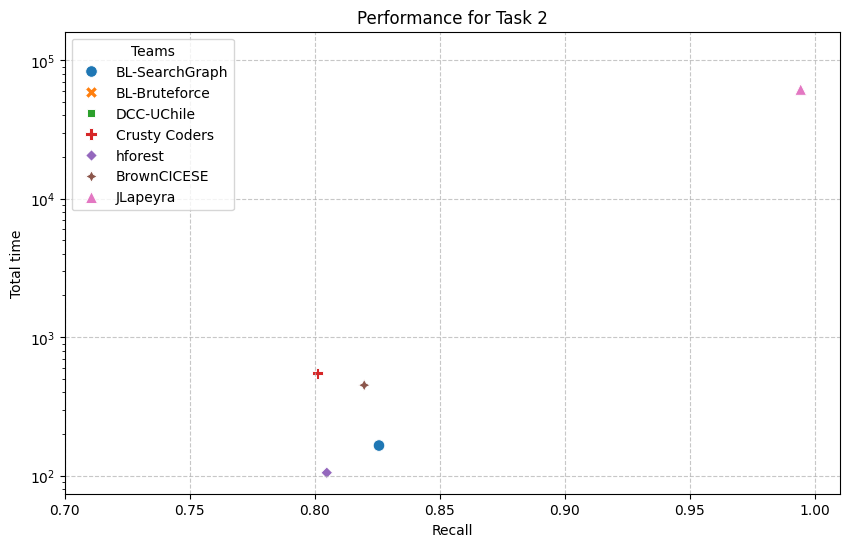

In [6]:
plt.figure(figsize=(10, 6))
#task1 = df[df.task == 'task1']
task2 = df.query("task == 'task2'") # and total_time <= 12 * 60 * 60")

display(task2)
sns.scatterplot(x='recall', y='total_time', hue='team', style='team', markers=True, s=70, data=task2)

plt.title('Performance for Task 2')
plt.xlabel('Recall')
plt.ylabel('Total time') 
plt.yscale('log')
plt.xlim(((0.7, 1.01)))
plt.legend(title='Teams')
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig("fig-task2.png", dpi=300, bbox_inches='tight')
plt.show()

In [7]:
task2 = df.query("task == 'task2'")

R = {
    'team': [],
    'k': [],
    'recall': [],
    'buildtime': [],
    'querytime': [],
    #'throughput': [],
    'total_time': [],
    'params': [],
}

for name, g in task2.groupby(by='team'):
    if len(g.team) == 0:
        continue
    
    G = g.iloc[0]
    R['team'].append(G.team)
    R['k'].append(G.k)
    R['recall'].append(G.recall)
    R['buildtime'].append(G.buildtime)
    R['querytime'].append(G.querytime)
    #R['throughput'].append(G.throughput)
    R['params'].append(G.params)
    R['total_time'].append(G.total_time)

R = pd.DataFrame(R)
#print(R.to_latex(float_format="%.4f"))
L = R.to_latex(index=False, formatters={
    "recall": lambda x: f"{x:.4f}",
    "buildtime": lambda x: f"{x:.0f}s",
    "querytime": lambda x: f"{x:.0f}s",
    "total_time": lambda x: f"{x:.0f}s",
    "throughput": lambda x: f"{x:.0f} q/s",
    })

display(R)
print(L)


,team,k,recall,buildtime,querytime,total_time,params
0,BL-Bruteforce,15,0.521013,0.000000e+00,9377.898455,9410.0,pca-i8 32;
1,BL-SearchGraph,15,0.825743,8.331754e+01,29.392259,165.0,pca-i8 160; MinRecall 0.9 ; Neighborhood{SatNe...
2,BrownCICESE,15,0.819839,9.080475e+00,437.450753,450.0,"index=(BrownCICESE),query=(M=52,H=26,O=100000,..."
3,Crusty Coders,15,0.801161,5.420000e+02,528.000000,548.0,NaN
4,DCC-UChile,15,0.543154,2.331547e+02,112970.109062,113213.0,"root_join_params: 1,1; PCA params: 0.8"
5,JLapeyra,15,0.994429,1.000000e+09,61430.494061,61433.0,"{""d_pca"": 140, ""k_search"": 200, ""no_self_loops..."
6,hforest,15,0.804859,0.000000e+00,98.904733,105.0,"index=(ntrees=80,leaf_size=10),query=(ntrees=8..."


\begin{tabular}{lrrrrrl}
\toprule
team & k & recall & buildtime & querytime & total_time & params \\
\midrule
BL-Bruteforce & 15 & 0.5210 & 0s & 9378s & 9410s & pca-i8 32; \\
BL-SearchGraph & 15 & 0.8257 & 83s & 29s & 165s & pca-i8 160; MinRecall 0.9 ; Neighborhood{SatNeighborhood} logbase 1.3 minsize Int32 2 filter SatNeighborhood \\
BrownCICESE & 15 & 0.8198 & 9s & 437s & 450s & index=(BrownCICESE),query=(M=52,H=26,O=100000,I=1) \\
Crusty Coders & 15 & 0.8012 & 542s & 528s & 548s & NaN \\
DCC-UChile & 15 & 0.5432 & 233s & 112970s & 113213s & root_join_params: 1,1; PCA params: 0.8 \\
JLapeyra & 15 & 0.9944 & 1000000000s & 61430s & 61433s & {"d_pca": 140, "k_search": 200, "no_self_loops": false} \\
hforest & 15 & 0.8049 & 0s & 99s & 105s & index=(ntrees=80,leaf_size=10),query=(ntrees=80,even=96,odd=97,dist=60,hops=0) \\
\bottomrule
\end{tabular}



# Memory usage

The following tables show the memory usage in terms of virtual and resident memory as understood by the Linux OS, and particularly collected with `docker top <RUNNING-CONTAINER> auwx` for each process in a second round evalution, i.e., independent of the one used to produce the performance tables.
We sampled with `docker top` the running container every 4seconds; we summed up memory per sample and present median and maximum for the entire memory series. The table shows numbers in GB.

In [8]:
D = pd.read_csv("memtable.csv")
D.query("task == 'task1'")

,team,task,vmem_median,vmem_max,rmem_median,rmem_max
0,bl-searchgraph,task1,14.484695,17.964378,9.602005,13.174229
2,browncicese,task1,20.312401,20.401394,14.227402,14.316364
4,cm-lll,task1,16.259254,16.259254,11.553612,11.585476
5,crustycoders,task1,32.581425,32.581425,14.462202,14.462921
8,hforest,task1,12.484932,20.762516,12.167664,15.985558
10,jlapeyra,task1,17.290352,21.413803,7.869053,15.333126
12,teamdoublefiltering,task1,9.702095,9.704338,9.572742,9.578808


Note that teams reaching close to 16GB of resident memory were those requiring swap to work. 

In [9]:
D.query("task == 'task2'")

,team,task,vmem_median,vmem_max,rmem_median,rmem_max
1,bl-searchgraph,task2,6.690327,7.371307,1.909630,2.259853
3,browncicese,task2,12.310337,12.310337,6.246105,6.246105
6,crustycoders,task2,6.475365,7.227318,3.101519,3.133228
7,dcc-chile,task2,18.258606,26.100815,8.161695,15.968651
9,hforest,task2,8.167755,8.167755,7.082756,7.350769
11,jlapeyra,task2,13.853859,18.341633,5.438824,14.804054
